In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
from coffea import util
from coffea.processor import accumulate
import os
import re
import pandas as pd
import hist
import matplotlib as mpl
import mplhep
import sys
import hist
import hist.intervals

sys.path.append("../analysisTools/")
import plotTools as ptools
import utils

In [2]:
f_sig = "../coffea/AllInOne_2022/AllInOne.coffea"

#Nested Dictionary:
sig_histo = util.load(f_sig) [0]

Saved: ./plots/signal_2018/gen_ele_vxy10_m110.png
Saved: ./plots/signal_2018/gen_ele_vxy10_m110.png
Saved: ./plots/signal_2018/gen_ele_vxy10_m110.png
average= [5000.66666667 2398.         1393.33333333  824.66666667  564.
  445.33333333  304.          216.          168.66666667  138.
  197.33333333  114.           82.66666667   47.33333333   52.        ]


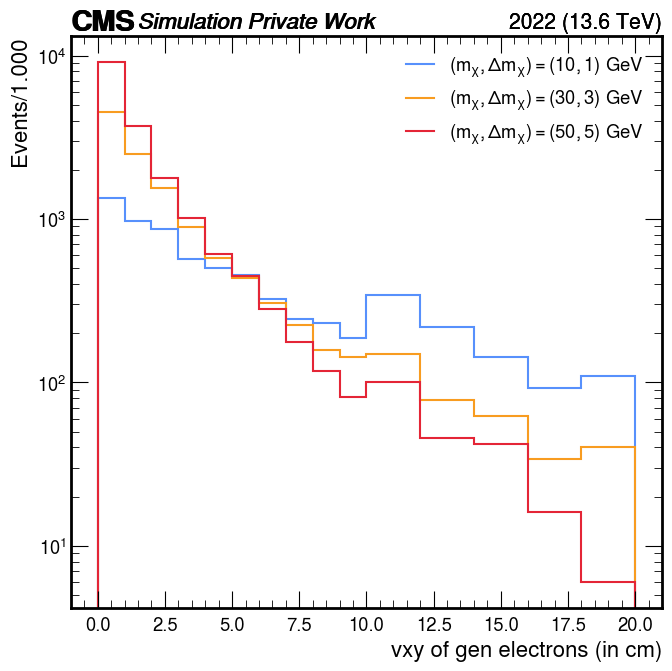

In [3]:
fig, ax = plt.subplots(figsize=(7,7))

delta =0.1
ctau =10

# Plot settings
plot_dict = {
    'variable':'gen_ele_vxy1',
    'cut': 'cut3',
    'year': 2022
}

style_dict = {
    'fig': fig,
    'ax': ax,
    'rebin': None,
    'xlim': None,     # if None, the default will show up; otherwise give as a list, i.e. [0, 10]
    'doLogy': True, 
    'doLogx': False,
    'doDensity': False,
    'doYerr': False, 
    'xlabel': "vxy of gen electrons (in cm)",   # if None, the default will show up; otherwise give as a string, i.e. 'Electron dxy'
    'ylabel': None,   # if None, the default will show up; otherwise give as a string, i.e. 'Efficiency'
    'label': None,    # if None, the default will show up; otherwise give as a string, i.e. 'Highest ctau signal samples'
    'flow': None,     # overflow
    'doSave': True,
    'outDir': './plots/signal_2018',
    'outName': f'gen_ele_vxy10_m110.png'
}



#signal points
m1s=[10,30,50]
delta =0.1
ctau =10


results = [
    ptools.plot_signal_1D(sig_histo, m1, delta, ctau, plot_dict, style_dict)
    
    for m1 in m1s
]

counts, edges = zip(*results)

counts = np.array(counts)     # shape: (n_m1, n_bins)
edges  = np.array(edges)      # shape: (n_m1, n_edges)

# counts, edges = ptools.plot_signal_1D(sig_histo, m1, delta, ctau, plot_dict, style_dict)


mask = counts != 0

bins_x = (edges[:,:-1] + edges[:,1:])*(0.5)

counts_nonzero_den = np.where(mask, counts, np.nan)
edges_nonzero_den  = np.where(mask, bins_x, np.nan)


avg_den = np.mean(counts_nonzero_den, axis=0)
print("average=", avg_den)


# total = np.sum(counts_nonzero_den)
# print ("TOTAL number of gen electrons:", total)


Saved: ./plots/signal_2018/match_ele_gen_vxy10_m110.png
Saved: ./plots/signal_2018/match_ele_gen_vxy10_m110.png
Saved: ./plots/signal_2018/match_ele_gen_vxy10_m110.png
average= [1857.          856.          489.          335.33333333  231.66666667
  183.33333333  124.           91.           73.           61.66666667
   69.66666667   33.66666667   27.66666667   15.66666667   15.33333333]
Saved: ./plots/signal_2018/match_ele_gen_vxy10_m110.png
Saved: ./plots/signal_2018/match_ele_gen_vxy10_m110.png
Saved: ./plots/signal_2018/match_ele_gen_vxy10_m110.png
average= [3027.66666667 1462.          812.66666667  457.66666667  315.33333333
  244.          157.66666667   97.           80.33333333   65.
   73.           35.           28.66666667   16.           15.33333333]


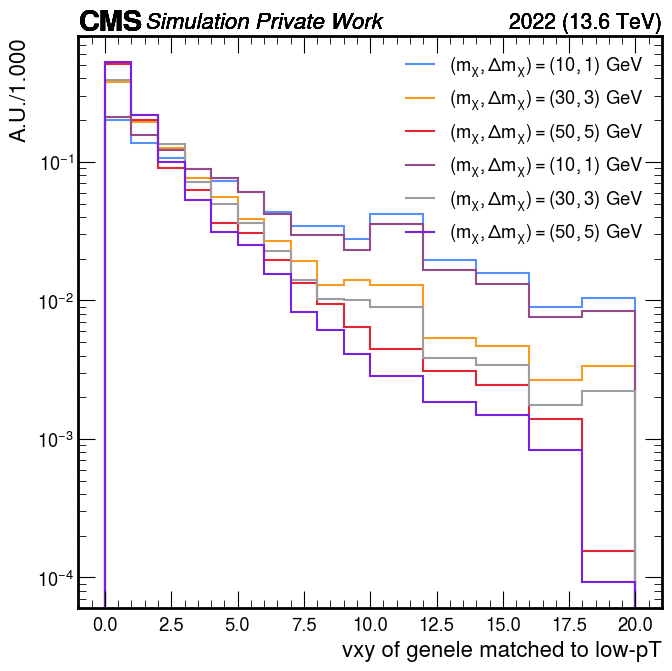

In [4]:
fig, ax = plt.subplots(figsize=(7,7))

plot_dict = {'variable': 'vxy_genElePos_Lpt', 'cut': 'cut3', 'year': 2022}

style_dict = {
    'fig': fig,
    'ax': ax,
    'rebin': None,
    'xlim': None,     # if None, the default will show up; otherwise give as a list, i.e. [0, 10]
    'doLogy': True, 
    'doLogx': False,
    'doDensity': True,
    'doYerr': False, 
    #'xlabel': "pT of gen electrons(matched to 'R')",  
    'xlabel': "vxy of genele matched to low-pT",              # if None, the default will show up; otherwise give as a string, i.e. 'Electron dxy'
    'ylabel': None,   # if None, the default will show up; otherwise give as a string, i.e. 'Efficiency'
    'label': None  ,    # if None, the default will show up; otherwise give as a string, i.e. 'Highest ctau signal samples'
    'flow': None,     # overflow
    'doSave': True,
    'outDir': './plots/signal_2018',
    'outName': f'match_ele_gen_vxy10_m110.png'
}

#signal points
m1s=[10,30,50]
delta =0.1
ctau =10


results_xcleaned = [
    ptools.plot_signal_1D(sig_histo, m1, delta, ctau, plot_dict, style_dict)
    
    for m1 in m1s
]

counts_xcleaned, edges_xcleaned = zip(*results_xcleaned)

counts_xcleaned = np.array(counts_xcleaned)     # shape: (n_m1, n_bins)
edges_xcleaned  = np.array(edges_xcleaned)      # shape: (n_m1, n_edges)


bins_x_xcleaned = (edges_xcleaned[:,:-1] + edges_xcleaned[:,1:])*(0.5)



avg_num_Xcleanedcase = np.mean(counts_xcleaned, axis=0)
print("average=", avg_num_Xcleanedcase)

################################################################################################################################



plot_dict = {'variable': 'vxy_genElePos_Lpt_Noxclean', 'cut': 'cut3', 'year': 2022}

style_dict = {
    'fig': fig,
    'ax': ax,
    'rebin': None,
    'xlim': None,     # if None, the default will show up; otherwise give as a list, i.e. [0, 10]
    'doLogy': True, 
    'doLogx': False,
    'doDensity': True,
    'doYerr': False, 
    #'xlabel': "pT of gen electrons(matched to 'R')",  
    'xlabel': "vxy of genele matched to low-pT",              # if None, the default will show up; otherwise give as a string, i.e. 'Electron dxy'
    'ylabel': None,   # if None, the default will show up; otherwise give as a string, i.e. 'Efficiency'
    'label': None  ,    # if None, the default will show up; otherwise give as a string, i.e. 'Highest ctau signal samples'
    'flow': None,     # overflow
    'doSave': True,
    'outDir': './plots/signal_2018',
    'outName': f'match_ele_gen_vxy10_m110.png'
}


#signal points
m1s=[10,30,50]
delta =0.1
ctau =10


results_noxcleaned = [
    ptools.plot_signal_1D(sig_histo, m1, delta, ctau, plot_dict, style_dict)
    
    for m1 in m1s
]

counts_noxcleaned, edges_noxcleaned = zip(*results_noxcleaned)

counts_noxcleaned = np.array(counts_noxcleaned)     # shape: (n_m1, n_bins)
edges_noxcleaned  = np.array(edges_noxcleaned)      # shape: (n_m1, n_edges)


bins_x_noxcleaned = (edges_noxcleaned[:,:-1] + edges_noxcleaned[:,1:])*(0.5)



avg_num_noXcleanedcase = np.mean(counts_noxcleaned, axis=0)
print("average=", avg_num_noXcleanedcase)

Saved: ./plots/signal_2018/match_ele_gen_vxy10_m110.png
Saved: ./plots/signal_2018/match_ele_gen_vxy10_m110.png
Saved: ./plots/signal_2018/match_ele_gen_vxy10_m110.png
average= [1.26400000e+03 6.49333333e+02 3.47666667e+02 1.34333333e+02
 9.03333333e+01 6.63333333e+01 3.53333333e+01 8.66666667e+00
 9.00000000e+00 4.66666667e+00 4.00000000e+00 2.33333333e+00
 1.00000000e+00 6.66666667e-01 3.33333333e-01]


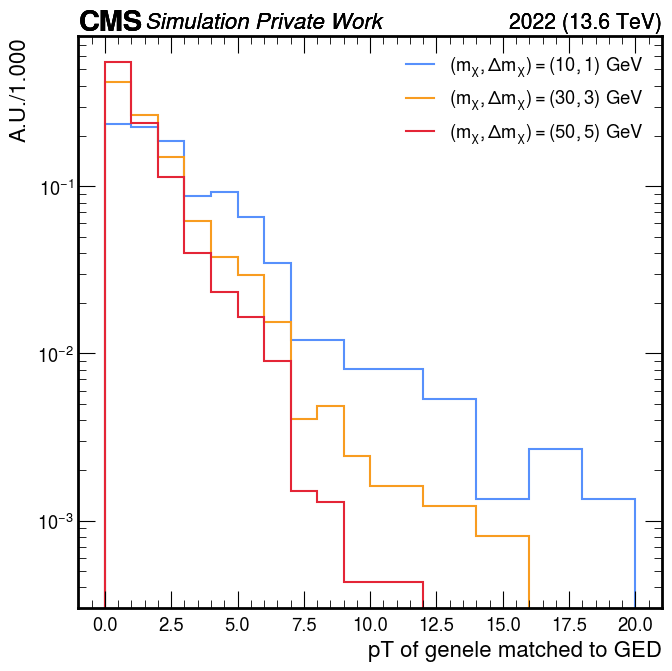

In [5]:
fig, ax = plt.subplots(figsize=(7,7))



plot_dict = {'variable': 'vxy_genElePos_GED', 'cut': 'cut3', 'year': 2022}

style_dict = {
    'fig': fig,
    'ax': ax,
    'rebin': None,
    'xlim': None,     # if None, the default will show up; otherwise give as a list, i.e. [0, 10]
    'doLogy': True, 
    'doLogx': False,
    'doDensity': True,
    'doYerr': False, 
    #'xlabel': "pT of gen electrons(matched to 'R')",  
    'xlabel': "pT of genele matched to GED",              # if None, the default will show up; otherwise give as a string, i.e. 'Electron dxy'
    'ylabel': None,   # if None, the default will show up; otherwise give as a string, i.e. 'Efficiency'
    'label': None  ,    # if None, the default will show up; otherwise give as a string, i.e. 'Highest ctau signal samples'
    'flow': None,     # overflow
    'doSave': True,
    'outDir': './plots/signal_2018',
    'outName': f'match_ele_gen_vxy10_m110.png'
}

#signal points
m1s=[10,30,50]
delta =0.1
ctau =10


results_GED = [
    ptools.plot_signal_1D(sig_histo, m1, delta, ctau, plot_dict, style_dict)
    
    for m1 in m1s
]

counts_GED, edges_GED = zip(*results_GED)

counts_GED = np.array(counts_GED)     # shape: (n_m1, n_bins)
edges_GED  = np.array(edges_GED)      # shape: (n_m1, n_edges)


bins_x_GED = (edges_GED[:,:-1] + edges_GED[:,1:])*(0.5)



avg_num_GED = np.mean(counts_GED, axis=0)
print("average=", avg_num_GED)


In [6]:
def eff_determine_unc(n, d):
    eff = np.divide(n, d)
    unc = hist.intervals.ratio_uncertainty(n, d, 'efficiency')
    return eff, unc


efficiency_noxclean, unc_eff_noxclean = eff_determine_unc(avg_num_noXcleanedcase, avg_den)
print ("efficiency_noxclean:",efficiency_noxclean)

efficiency_xcleaned, unc_eff_xcleaned = eff_determine_unc(avg_num_Xcleanedcase, avg_den)
print ("efficiency_xcleaned:",efficiency_xcleaned)

efficiency_GED, unc_eff_GED = eff_determine_unc(avg_num_GED, avg_den)
print ("efficiency_GED:",efficiency_GED)

efficiency_noxclean: [0.60545261 0.60967473 0.58325359 0.55497171 0.55910165 0.54790419
 0.51864035 0.44907407 0.47628458 0.47101449 0.36993243 0.30701754
 0.34677419 0.33802817 0.29487179]
efficiency_xcleaned: [0.37135049 0.35696414 0.35095694 0.40662894 0.4107565  0.41167665
 0.40789474 0.4212963  0.43280632 0.4468599  0.35304054 0.29532164
 0.33467742 0.33098592 0.29487179]
efficiency_GED: [0.2527663  0.27078121 0.24952153 0.1628941  0.16016548 0.1489521
 0.11622807 0.04012346 0.05335968 0.03381643 0.02027027 0.02046784
 0.01209677 0.01408451 0.00641026]


In [7]:
print ("bins_x_noxcleaned=", bins_x_noxcleaned)
print ("bins_x_xcleaned=", bins_x_xcleaned)
print ("bins_x_GED=", bins_x_GED)

bins_x_noxcleaned= [[ 0.5  1.5  2.5  3.5  4.5  5.5  6.5  7.5  8.5  9.5 11.  13.  15.  17.
  19. ]
 [ 0.5  1.5  2.5  3.5  4.5  5.5  6.5  7.5  8.5  9.5 11.  13.  15.  17.
  19. ]
 [ 0.5  1.5  2.5  3.5  4.5  5.5  6.5  7.5  8.5  9.5 11.  13.  15.  17.
  19. ]]
bins_x_xcleaned= [[ 0.5  1.5  2.5  3.5  4.5  5.5  6.5  7.5  8.5  9.5 11.  13.  15.  17.
  19. ]
 [ 0.5  1.5  2.5  3.5  4.5  5.5  6.5  7.5  8.5  9.5 11.  13.  15.  17.
  19. ]
 [ 0.5  1.5  2.5  3.5  4.5  5.5  6.5  7.5  8.5  9.5 11.  13.  15.  17.
  19. ]]
bins_x_GED= [[ 0.5  1.5  2.5  3.5  4.5  5.5  6.5  7.5  8.5  9.5 11.  13.  15.  17.
  19. ]
 [ 0.5  1.5  2.5  3.5  4.5  5.5  6.5  7.5  8.5  9.5 11.  13.  15.  17.
  19. ]
 [ 0.5  1.5  2.5  3.5  4.5  5.5  6.5  7.5  8.5  9.5 11.  13.  15.  17.
  19. ]]


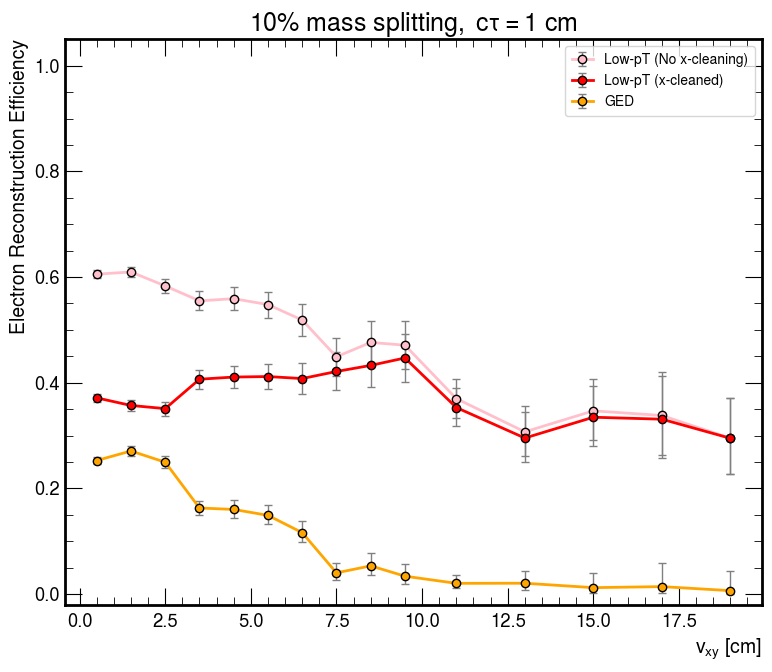

In [11]:
plt.figure(figsize=(8,7))

plt.errorbar(
    bins_x_noxcleaned[0,:],
    efficiency_noxclean,
    yerr=unc_eff_noxclean,
    fmt='o-',
    linewidth=2,
    markersize=6,
    color='pink',
    markeredgecolor='black',
    ecolor='gray',
    elinewidth=1,
    capsize=3,
    label='Low-pT (No x-cleaning)'
)

plt.errorbar(
    bins_x_xcleaned[0,:],
    efficiency_xcleaned,
    yerr=unc_eff_xcleaned,
    fmt='o-',
    linewidth=2,
    markersize=6,
    color='red',
    markeredgecolor='black',
    ecolor='gray',
    elinewidth=1,
    capsize=3,
    label='Low-pT (x-cleaned)'
)

plt.errorbar(
    bins_x_GED[0,:],
    efficiency_GED,
    yerr=unc_eff_GED,
    fmt='o-',
    linewidth=2,
    markersize=6,
    color='orange',
    markeredgecolor='black',
    ecolor='gray',
    elinewidth=1,
    capsize=3,
    label='GED'
)

# Axis styling
plt.ylim(-0.02, 1.05)
plt.xlabel(r"$v_{xy}$ [cm]", fontsize=14)
plt.ylabel("Electron Reconstruction Efficiency", fontsize=14)



# Grid helps readability
# plt.grid(True, linestyle='--', alpha=0.4)

# Better title formatting


plt.title(
    
    r"$10\%\ \mathrm{mass\ splitting},\ c\tau = 1\ \mathrm{cm}$",
    fontsize=18
)



plt.legend(fontsize=10, frameon=True, loc='upper right')

plt.tight_layout()

plt.savefig("L_lxy_ERE.png", dpi=300)